# 메이플스토리 주차 유저 클러스터링 — EDA (v2)

> **입력**: `../data/features_monthly.csv` (12개월 스냅샷 기반, 2,000명) + `../data/main_characters.csv` (class_group)
>
> **목적 1**: H1/H2/H3 가설 검증에 필요한 데이터 가공·전처리 결정 확정
> **목적 2**: 가설 외 추가 인사이트 (정체지수, 경험치, 심볼 포화도) 발굴
>
> **흐름**: Sec0 환경 → Sec1 품질 → Sec2 단변량 → Sec3 이변량 → Sec4 직업계열 → Sec5 레벨구간+H2 사전 → Sec6 경험치 → Sec7 심볼 → Sec8 정체지수 → Sec9 가설 검증 가능성 → Sec10 최종 전처리·피처셋


## Sec 0. 환경 설정 및 데이터 로드

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr
from scipy.stats.mstats import winsorize
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
import matplotlib.font_manager as fm
font_path = Path('../assets/NanumSquareNeo-bRg.ttf')
if font_path.exists():
    fe = fm.FontEntry(fname=str(font_path), name='NanumSquareNeo')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams['font.family'] = fe.name
else:
    import platform
    plt.rcParams['font.family'] = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

# ── 분석 상수 ───────────────────────────────────────────────────────────────
ARCANE_MAX = 120
DELTA_COLS = [
    'avg_monthly_delta_level',
    'avg_monthly_delta_combat_power',
    'avg_monthly_delta_union_level',
    'avg_monthly_delta_arcane_symbol',
    'avg_monthly_delta_authentic_symbol',
]
LEVEL_BIN_ORDER = ['260-269', '270-279', '280-285']
BIN_PALETTE = {'260-269': '#4e79a7', '270-279': '#f28e2b', '280-285': '#e15759'}
GROUP_ORDER = ['전사', '마법사', '궁수', '도적', '해적']  # 수집 단계에서 5계열 층화 완료 (기타/결측 없음 — Sec 1 확인)
print('imports OK')

imports OK


In [2]:
# 데이터 로드 + class_group 병합
df_raw = pd.read_csv('../data/features_monthly.csv', encoding='utf-8-sig')
mc = pd.read_csv('../data/main_characters.csv', encoding='utf-8-sig', usecols=['ocid', 'class_group'])
df = df_raw.merge(mc, on='ocid', how='left')

# 레벨 구간 (수집 시 사용한 동일 경계: 260-269 / 270-279 / 280-285)
df['level_bin'] = pd.cut(df['level'], bins=[259, 269, 279, 285], labels=LEVEL_BIN_ORDER)

print(f'features_monthly: {df_raw.shape}, merged: {df.shape}')
print(f'class_group 결측: {df["class_group"].isna().sum()}행 (병합 실패)')
print(f'수집 윈도우: {df["first_valid_month"].iloc[0]} ~ {df["last_valid_month"].iloc[0]} (num_valid_months 항상 {df["num_valid_months"].iloc[0]})')

df.describe(include=[np.number]).T.round(2)

features_monthly: (2000, 18), merged: (2000, 20)
class_group 결측: 0행 (병합 실패)
수집 윈도우: 2025-06 ~ 2026-05 (num_valid_months 항상 12)


,count,mean,std,min,25%,50%,75%,max
level,1921.0,2.729100e+02,8.750000e+00,200.00,2.630000e+02,2.740000e+02,2.800000e+02,2.850000e+02
union_level,1823.0,6.252130e+03,2.958840e+03,221.00,3.627000e+03,7.435000e+03,8.806000e+03,1.036600e+04
arcane_symbol_score,2000.0,9.621000e+01,3.165000e+01,0.00,8.000000e+01,1.120000e+02,1.200000e+02,1.200000e+02
authentic_symbol_score,2000.0,1.679000e+01,1.276000e+01,0.00,5.000000e+00,1.600000e+01,2.600000e+01,5.500000e+01
exp,1921.0,7.359962e+12,1.080750e+13,31269087.00,8.112855e+11,1.852144e+12,7.250986e+12,4.891313e+13
log_exp,1921.0,2.841000e+01,1.930000e+00,17.26,2.742000e+01,2.825000e+01,2.961000e+01,3.152000e+01
avg_monthly_delta_level,1750.0,7.500000e-01,3.170000e+00,0.00,0.000000e+00,0.000000e+00,4.000000e-01,5.500000e+01
avg_monthly_delta_combat_power,1757.0,-8.136777e+04,4.218794e+06,-95529488.33,-2.957174e+05,0.000000e+00,1.662169e+05,4.490494e+07
avg_monthly_delta_union_level,1689.0,4.437000e+01,1.259100e+02,-451.18,0.000000e+00,1.820000e+00,3.060000e+01,2.142000e+03
avg_monthly_delta_arcane_symbol,2000.0,3.840000e+00,4.580000e+00,-10.18,0.000000e+00,0.000000e+00,8.550000e+00,1.091000e+01


## Sec 1. 데이터 품질 진단

전처리 결정에 필요한 결측·이상치 근거를 수집한다.
v2 수집 결과 특이사항을 먼저 카탈로그화한 뒤 분석용 `df_clean` 정의.


In [3]:
# 결측치 현황
null_s = df.isnull().sum()
null_pct = (null_s / len(df) * 100).round(2)
null_tbl = pd.DataFrame({'결측수': null_s, '결측률(%)': null_pct})
null_tbl = null_tbl[null_tbl['결측수'] > 0].sort_values('결측수', ascending=False)
print('[컬럼별 결측]')
print(null_tbl.to_string())

[컬럼별 결측]
                                결측수  결측률(%)
avg_monthly_delta_union_level   311   15.55
avg_monthly_delta_level         250   12.50
avg_monthly_delta_combat_power  243   12.15
union_level                     177    8.85
level_bin                        89    4.45
log_exp                          79    3.95
level                            79    3.95
exp                              79    3.95


In [4]:
# 결측 구조 해석 — 필드 단위 결측 + MCAR 검토
print('=== 결측 패턴 ===')

# num_valid_months 는 "character/basic 응답이 온 월 수"일 뿐, 개별 필드 유효성이 아니다.
nvm = sorted(df['num_valid_months'].dropna().unique().tolist())
print(f'num_valid_months 고유값: {nvm}  → 전 행 동일(= basic 응답 횟수). 실제 결측은 필드 단위로 발생.\n')

level_nan = df['level'].isna()
print(f'1. level NaN: {level_nan.sum()}행')
print(f'   → 마지막 유효월 basic 의 character_level 이 null (신규 생성·기록 희소 OCID). 전 수치 컬럼 NaN → 제외 필수.')

dlv_nan = df['avg_monthly_delta_level'].isna()
print(f'2. Δlevel NaN: {dlv_nan.sum()}행 ({dlv_nan.mean()*100:.1f}%)')
print(f'   → level 값이 존재하는 월이 2개 미만 → 변화량 산출 불가. 분석 제외.')

core = DELTA_COLS[:3]   # Δlevel / Δcp / Δunion
core_all_nan = df[core].isnull().all(axis=1)
core_any_nan = df[core].isnull().any(axis=1)
print(f'3. 핵심 3-delta 전부 NaN: {core_all_nan.sum()}행  (level NaN {level_nan.sum()}행은 이 집합의 부분집합)')
print(f'   핵심 3-delta 중 하나라도 NaN: {core_any_nan.sum()}행  → listwise deletion 대상')

union_nan_only = df['union_level'].isna() & df['level'].notna()
print(f'4. union_level(스냅샷) NaN & level 정상: {union_nan_only.sum()}행  → 유니온 미가입 → 0 클램프')

# MCAR 검토: 핵심 delta 결측 행 vs 정상 행의 레벨 분포 비교
#   (level 자체가 NaN 인 행은 .mean() 에서 자동 제외되므로 사실상 'level 정상·delta 결측' 행이 비교 대상)
print(f'\nNaN 행 레벨 평균: {df.loc[core_any_nan, "level"].mean():.1f}  vs  정상 행: {df.loc[~core_any_nan, "level"].mean():.1f}')
print('→ 평균 레벨이 비슷하면 MCAR 가정 합리적 → listwise deletion 무편향.')

=== 결측 패턴 ===
num_valid_months 고유값: [12]  → 전 행 동일(= basic 응답 횟수). 실제 결측은 필드 단위로 발생.

1. level NaN: 79행
   → 마지막 유효월 basic 의 character_level 이 null (신규 생성·기록 희소 OCID). 전 수치 컬럼 NaN → 제외 필수.
2. Δlevel NaN: 250행 (12.5%)
   → level 값이 존재하는 월이 2개 미만 → 변화량 산출 불가. 분석 제외.
3. 핵심 3-delta 전부 NaN: 243행  (level NaN 79행은 이 집합의 부분집합)
   핵심 3-delta 중 하나라도 NaN: 311행  → listwise deletion 대상
4. union_level(스냅샷) NaN & level 정상: 98행  → 유니온 미가입 → 0 클램프

NaN 행 레벨 평균: 272.0  vs  정상 행: 273.0
→ 평균 레벨이 비슷하면 MCAR 가정 합리적 → listwise deletion 무편향.


In [5]:
# 특이 케이스 카탈로그
print('=== 특이 케이스 카탈로그 ===')
print(f'1. delta_cp < 0:          {(df["avg_monthly_delta_combat_power"] < 0).sum()}행 ({(df["avg_monthly_delta_combat_power"] < 0).mean()*100:.1f}%)  ← 장비 교체·통계 노이즈')
print(f'2. delta_union < 0:       {(df["avg_monthly_delta_union_level"] < 0).sum()}행                          ← 유니온 재편성')
print(f'3. delta_arcane < 0:      {(df["avg_monthly_delta_arcane_symbol"] < 0).sum()}행                          ← 시스템상 0으로 클램프 권장')
print(f'4. delta_authentic < 0:   {(df["avg_monthly_delta_authentic_symbol"] < 0).sum()}행                          ← 시스템상 0으로 클램프 권장')
print(f'5. level == 285:          {(df["level"] == 285).sum()}행 ({(df["level"] == 285).mean()*100:.1f}%)            ← 만렙(레벨 정체 자연 발생)')
print(f'6. delta_level == 0:      {((df["avg_monthly_delta_level"] == 0) & df["avg_monthly_delta_level"].notna()).sum()}행 ({((df["avg_monthly_delta_level"] == 0) & df["avg_monthly_delta_level"].notna()).mean()*100:.1f}%)')
print(f'7. arcane_score == 120:   {(df["arcane_symbol_score"] == 120).sum()}행 ({(df["arcane_symbol_score"] == 120).mean()*100:.1f}%) ← 포화')
print(f'8. authentic_score MAX:   {df["authentic_symbol_score"].max()} (이론 한계 88)')

=== 특이 케이스 카탈로그 ===
1. delta_cp < 0:          621행 (31.1%)  ← 장비 교체·통계 노이즈
2. delta_union < 0:       12행                          ← 유니온 재편성
3. delta_arcane < 0:      2행                          ← 시스템상 0으로 클램프 권장
4. delta_authentic < 0:   4행                          ← 시스템상 0으로 클램프 권장
5. level == 285:          80행 (4.0%)            ← 만렙(레벨 정체 자연 발생)
6. delta_level == 0:      996행 (49.8%)
7. arcane_score == 120:   906행 (45.3%) ← 포화
8. authentic_score MAX:   55 (이론 한계 88)


In [6]:
# class_group 병합 건전성 점검 — collect_main_characters.py 가 5계열 층화수집 완료
print('=== class_group 분포 ===')
vc = df['class_group'].value_counts(dropna=False)
print(vc.to_string())

n_na  = df['class_group'].isna().sum()
n_etc = (df['class_group'] == '기타').sum()
groups = set(df['class_group'].dropna().unique())

print(f'\n병합 실패(NaN): {n_na}행 | "기타": {n_etc}행')
if n_na == 0 and n_etc == 0 and groups == set(GROUP_ORDER):
    bal = df['class_group'].value_counts().reindex(GROUP_ORDER)
    print(f'→ 5계열 {GROUP_ORDER} 모두 존재, 각 {int(bal.min())}~{int(bal.max())}명.')
    print('  수집 단계 층화가 완료되어 EDA에서 별도 그루핑/"기타" 처리 불필요.')
    print('  H2 직업×클러스터: 5계열 전체 사용 | H3: 직업명은 피처 아님(군집/rule만 평가).')
else:
    print('→ ⚠ 예상과 다른 그룹/결측 발견 — 수집 매핑 점검 필요.')
    if n_etc:
        print(df.loc[df['class_group'] == '기타', 'character_class'].value_counts().head(20).to_string())

=== class_group 분포 ===
class_group
전사     400
마법사    400
궁수     400
도적     400
해적     400

병합 실패(NaN): 0행 | "기타": 0행
→ 5계열 ['전사', '마법사', '궁수', '도적', '해적'] 모두 존재, 각 400~400명.
  수집 단계 층화가 완료되어 EDA에서 별도 그루핑/"기타" 처리 불필요.
  H2 직업×클러스터: 5계열 전체 사용 | H3: 직업명은 피처 아님(군집/rule만 평가).


In [7]:
# df_clean 정의 — 분석 본판 (Sec 10 df_final 과 동일 모집단)
# 프로젝트 범위(260≤level≤285)로 한정 후 핵심 delta(level/cp/union) NaN 행 listwise 제거
df_clean = df[df['level'].between(260, 285)].dropna(subset=DELTA_COLS[:3]).copy()

# 시스템상 불가능한 음수 → 0 클램프
for c in ['avg_monthly_delta_arcane_symbol', 'avg_monthly_delta_authentic_symbol']:
    n_neg = (df_clean[c] < 0).sum()
    df_clean.loc[df_clean[c] < 0, c] = 0
    print(f'  {c}: {n_neg}행 클램프 → 0')

# union_level(마지막 월 스냅샷) 결측 → 유니온 미가입으로 보아 0
union_nan_n = df_clean['union_level'].isna().sum()
df_clean['union_level'] = df_clean['union_level'].fillna(0)
print(f'  union_level 결측 {union_nan_n}행 → 0으로 채움 (유니온 미가입)')

print(f'\ndf_clean: {df_clean.shape} (원본 {len(df)}행 중 {len(df) - len(df_clean)}행 제거)')
print(f'레벨 분포: min={df_clean["level"].min():.0f}, max={df_clean["level"].max():.0f}, '
      f'median={df_clean["level"].median():.0f} | level_bin 결측: {df_clean["level_bin"].isna().sum()}행 (0이어야 정상)')

  avg_monthly_delta_arcane_symbol: 2행 클램프 → 0
  avg_monthly_delta_authentic_symbol: 4행 클램프 → 0
  union_level 결측 0행 → 0으로 채움 (유니온 미가입)

df_clean: (1688, 20) (원본 2000행 중 312행 제거)
레벨 분포: min=260, max=285, median=274 | level_bin 결측: 0행 (0이어야 정상)


## Sec 2. 핵심 피처 단변량 분포

H1 군집 분리 가능성의 시각적 근거 — delta 피처가 0 부근에 좁은 봉우리(=주차 후보)와 분산된 꼬리(=정상 성장)로 나뉘는지 확인.


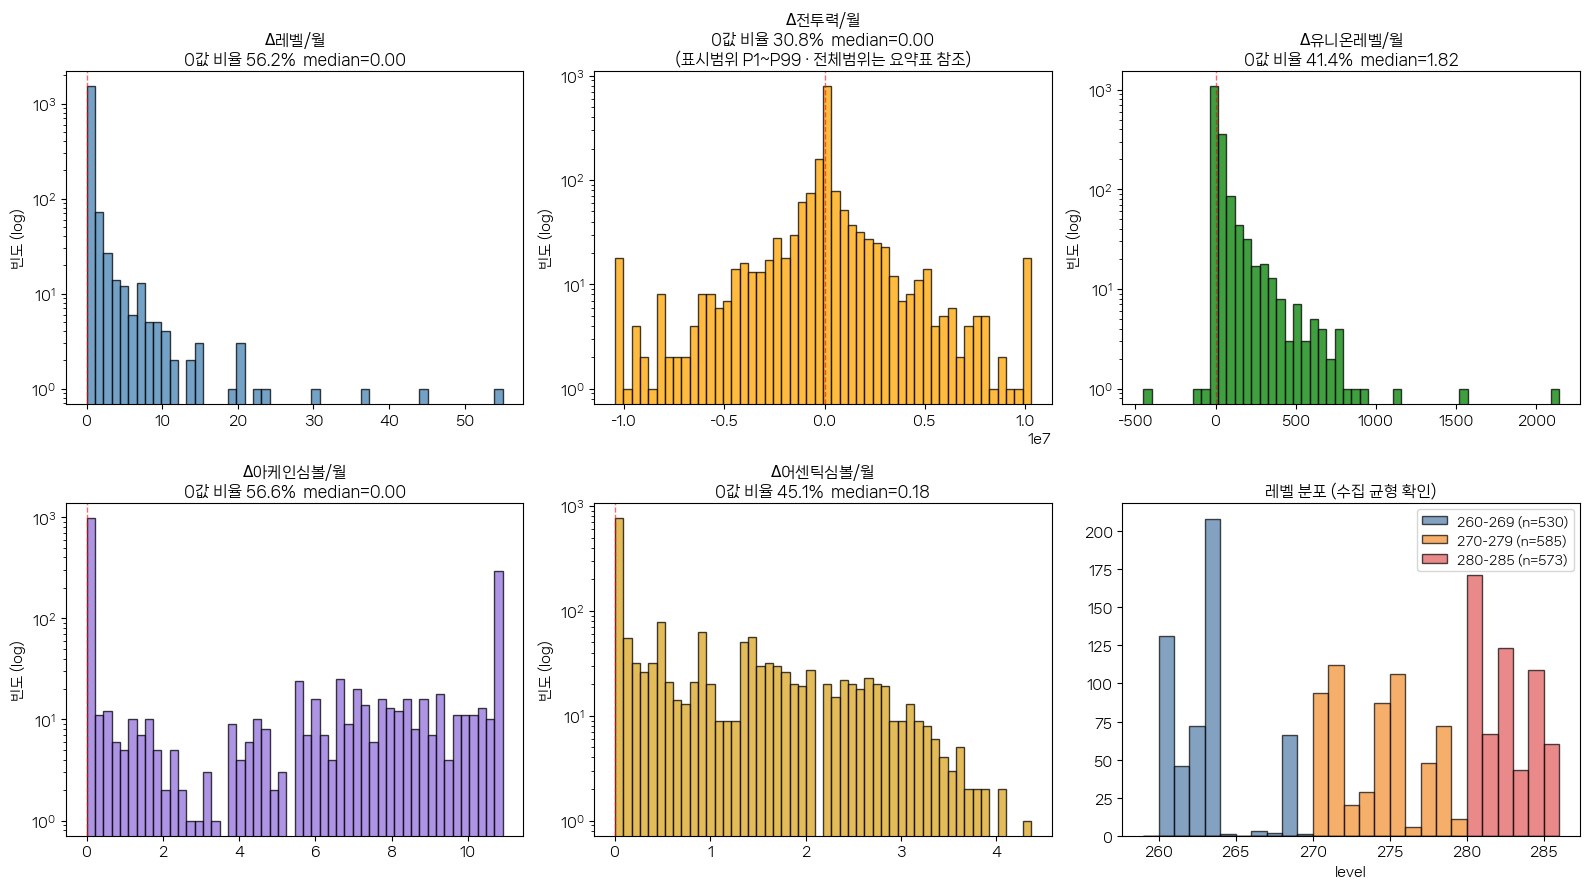

In [8]:
titles = [r'$\Delta$레벨/월', r'$\Delta$전투력/월', r'$\Delta$유니온레벨/월',
          r'$\Delta$아케인심볼/월', r'$\Delta$어센틱심볼/월']
colors = ['steelblue', 'orange', 'green', 'mediumpurple', 'goldenrod']
# Δcp 는 분산이 매우 커(±수천만) 원척도 히스토그램이 단일 막대로 뭉개짐 → P1~P99 클리핑 표시
clip_cols = {'avg_monthly_delta_combat_power'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col, title, color in zip(axes[:5], DELTA_COLS, titles, colors):
    raw = df_clean[col]
    zero_pct = (raw == 0).mean() * 100
    note = ''
    vals = raw
    if col in clip_cols:
        lo, hi = raw.quantile(0.01), raw.quantile(0.99)
        vals = raw.clip(lo, hi)
        note = '\n(표시범위 P1~P99 · 전체범위는 요약표 참조)'
    ax.hist(vals, bins=50, color=color, edgecolor='black', alpha=0.75)
    ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(f'{title}\n0값 비율 {zero_pct:.1f}%  median={raw.median():.2f}{note}', fontsize=11)
    ax.set_yscale('log')
    ax.set_ylabel('빈도 (log)')

# 마지막: level 분포 (레벨 구간 색상)
for band, color in BIN_PALETTE.items():
    sub = df_clean[df_clean['level_bin'] == band]['level']
    axes[5].hist(sub, bins=range(259, 287), color=color, edgecolor='black',
                  alpha=0.7, label=f'{band} (n={len(sub)})')
axes[5].set_title('레벨 분포 (수집 균형 확인)', fontsize=11)
axes[5].set_xlabel('level')
axes[5].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# 단변량 요약표
desc = df_clean[DELTA_COLS].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.round(3)
desc['zero_rate'] = [(df_clean[c] == 0).mean().round(3) for c in DELTA_COLS]
desc['neg_rate'] = [(df_clean[c] < 0).mean().round(3) for c in DELTA_COLS]
desc

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,zero_rate,neg_rate
avg_monthly_delta_level,1688.0,0.699,2.831,0.000000e+00,0.000,0.000,0.400,1.202,2.812,1.052500e+01,5.500000e+01,0.562,0.000
avg_monthly_delta_combat_power,1688.0,-61219.537,4283442.837,-9.552949e+07,-305557.017,0.000,188418.311,2226736.585,4236555.450,1.029975e+07,4.490494e+07,0.308,0.355
avg_monthly_delta_union_level,1688.0,44.391,125.945,-4.511820e+02,0.000,1.818,30.609,115.300,232.055,6.335430e+02,2.142000e+03,0.414,0.007
avg_monthly_delta_arcane_symbol,1688.0,3.462,4.551,0.000000e+00,0.000,0.000,8.182,10.909,10.909,1.090900e+01,1.090900e+01,0.566,0.000
avg_monthly_delta_authentic_symbol,1688.0,0.796,1.010,0.000000e+00,0.000,0.182,1.455,2.455,2.818,3.466000e+00,4.364000e+00,0.451,0.000


## Sec 3. 이변량 관계 분석

피처 간 다중공선성(VIF) 및 예상치 못한 관계를 확인한다.
H1 클러스터링 피처 셋을 줄여야 하는지 결정.


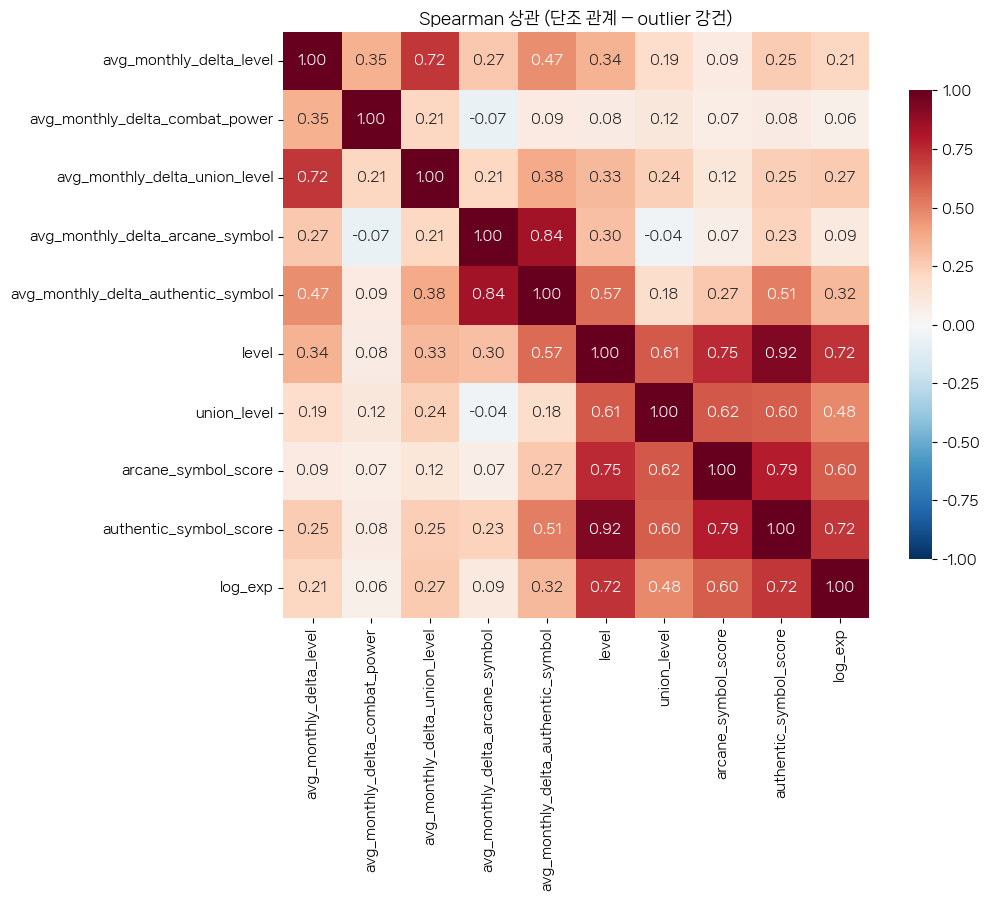

In [10]:
# Spearman 상관 — 모든 수치 컬럼
num_cols = DELTA_COLS + ['level', 'union_level', 'arcane_symbol_score', 'authentic_symbol_score', 'log_exp']
corr = df_clean[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Spearman 상관 (단조 관계 — outlier 강건)', fontsize=12)
plt.tight_layout()
plt.show()

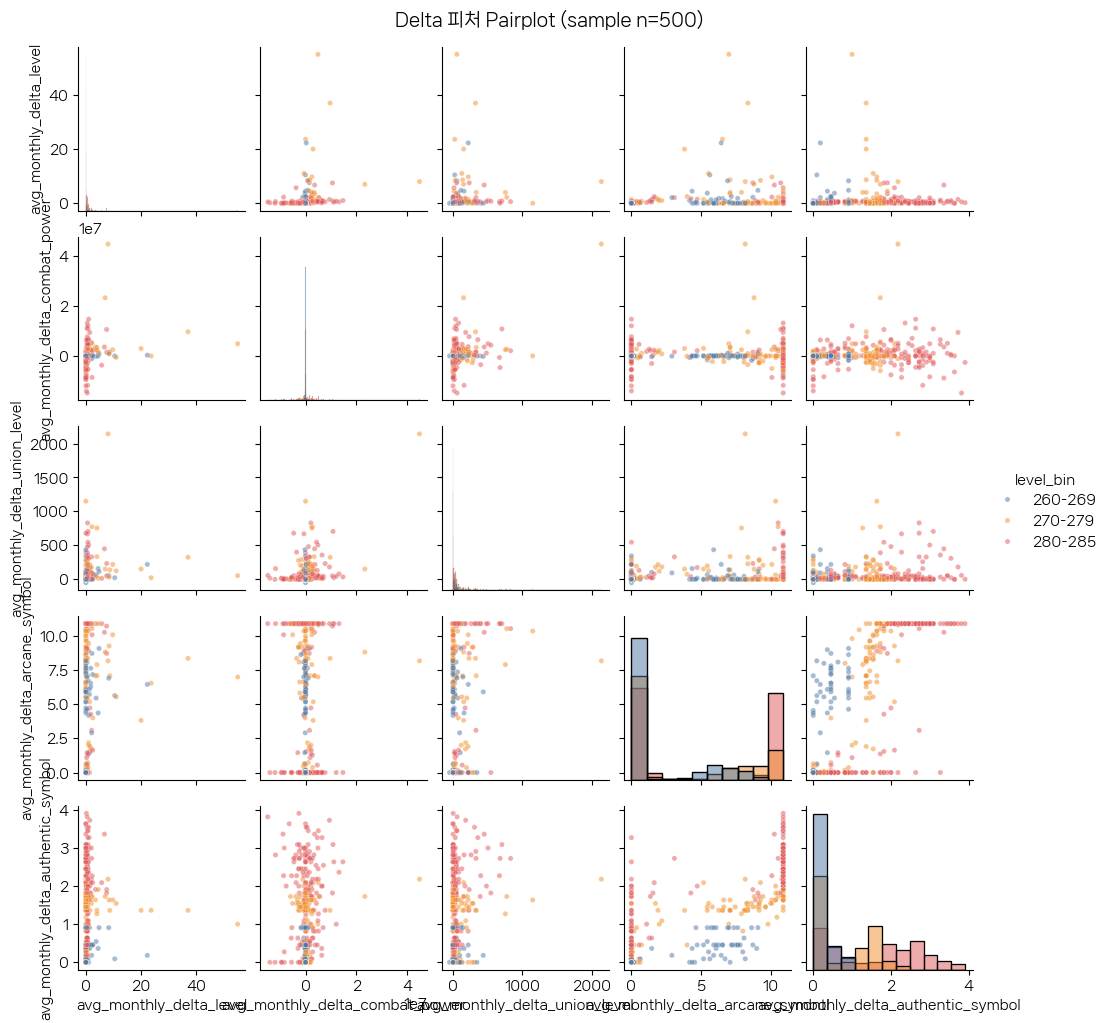

In [11]:
# Delta 피처 5개 pairplot — level_bin 색상
sample_n = min(500, len(df_clean))
df_pair = (df_clean[DELTA_COLS + ['level_bin']]
           .dropna(subset=['level_bin'])
           .sample(sample_n, random_state=42))

g = sns.pairplot(df_pair, hue='level_bin', palette=BIN_PALETTE,
                 vars=DELTA_COLS, plot_kws={'alpha': 0.5, 's': 14},
                 diag_kind='hist', height=2.0)
g.fig.suptitle(f'Delta 피처 Pairplot (sample n={sample_n})', y=1.02, fontsize=13)
plt.show()

In [12]:
# VIF — 클러스터링 피처 후보의 다중공선성
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X = df_clean[DELTA_COLS].dropna().copy()
    # 표준화 권장 (VIF는 스케일 무관하지만 수치 안정성)
    Xz = (X - X.mean()) / X.std().replace(0, 1)
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(Xz.values, i) for i in range(Xz.shape[1])]
    })
    print('[VIF — Delta 피처]')
    print(vif.round(2).to_string(index=False))
    print('\n해석: VIF < 5 → 다중공선성 없음, 5~10 → 주의, >10 → 제거 검토')
except ImportError:
    print('statsmodels 미설치')

[VIF — Delta 피처]
                           feature  VIF
           avg_monthly_delta_level 1.14
    avg_monthly_delta_combat_power 1.11
     avg_monthly_delta_union_level 1.22
   avg_monthly_delta_arcane_symbol 3.36
avg_monthly_delta_authentic_symbol 3.34

해석: VIF < 5 → 다중공선성 없음, 5~10 → 주의, >10 → 제거 검토


## Sec 4. 직업 계열 분포 분석 (H2 사전)

수집 시 5계열 × 400명 균형을 목표했으나 실제 분포를 점검한다.


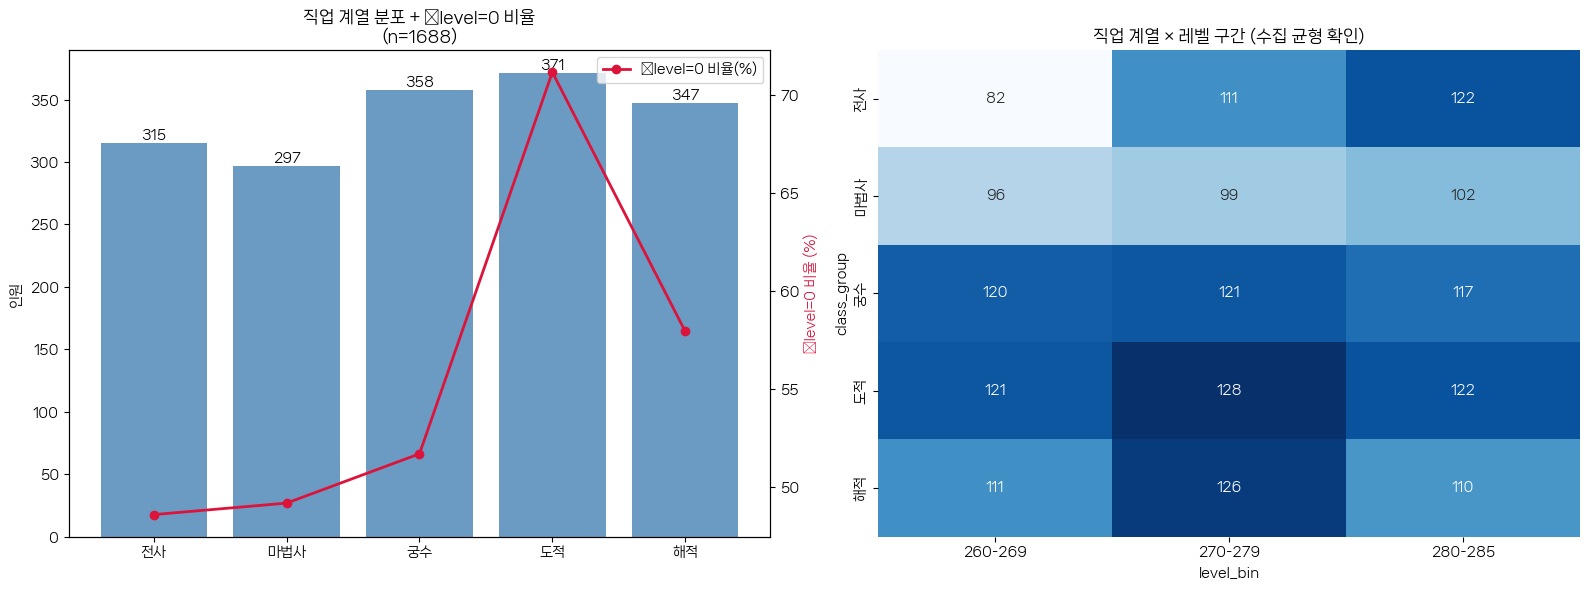


→ 수집 단계 5계열 균형 + 레벨구간 3등분 → H2 카이제곱 기대 빈도 ≥ 5 조건 사전 점검 (Sec 5).


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: class_group 분포 (delta_level 0값 비율 동시 표시) — 수집이 5계열 균형 완료
group_stats = (df_clean.groupby('class_group')
               .agg(인원=('character_name', 'count'),
                    delta0_pct=('avg_monthly_delta_level', lambda s: (s == 0).mean() * 100))
               .reindex(GROUP_ORDER))
ax = axes[0]
bars = ax.bar(group_stats.index, group_stats['인원'], color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(group_stats.index, group_stats['delta0_pct'], 'o-', color='crimson', linewidth=2,
         label='Δlevel=0 비율(%)')
ax.set_ylabel('인원')
ax2.set_ylabel('Δlevel=0 비율 (%)', color='crimson')
ax.set_title(f'직업 계열 분포 + Δlevel=0 비율\n(n={len(df_clean)})')
for b, v in zip(bars, group_stats['인원']):
    ax.text(b.get_x() + b.get_width()/2, v, str(int(v)), ha='center', va='bottom', fontsize=10)
ax2.legend(loc='upper right')

# 오른쪽: class_group × level_bin
ct = pd.crosstab(df_clean['class_group'], df_clean['level_bin']).reindex(GROUP_ORDER)
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('직업 계열 × 레벨 구간 (수집 균형 확인)')
plt.tight_layout()
plt.show()
print('\n→ 수집 단계 5계열 균형 + 레벨구간 3등분 → H2 카이제곱 기대 빈도 ≥ 5 조건 사전 점검 (Sec 5).')

In [14]:
# 직업 계열별 delta 통계 요약
df_grp = df_clean[df_clean['class_group'].isin(GROUP_ORDER)].copy()
print(f'5계열 분석 대상: {len(df_grp)}행 (5계열 전체 — 기타 없음)')
print()
print('[직업 계열별 delta 중앙값]')
print(df_grp.groupby('class_group')[DELTA_COLS].median().round(3).reindex(GROUP_ORDER).to_string())

5계열 분석 대상: 1688행 (5계열 전체 — 기타 없음)

[직업 계열별 delta 중앙값]
             avg_monthly_delta_level  avg_monthly_delta_combat_power  avg_monthly_delta_union_level  avg_monthly_delta_arcane_symbol  avg_monthly_delta_authentic_symbol
class_group                                                                                                                                                             
전사                             0.125                             0.0                          2.200                           10.182                               1.636
마법사                            0.091                             0.0                          5.182                            0.000                               0.273
궁수                             0.000                             0.0                          7.045                            0.000                               0.000
도적                             0.000                             0.0                          0.000  

## Sec 5. 레벨 구간 분석 및 H2 Chi-Square 사전 검토

수집 경계 그대로 사용: **260-269 / 270-279 / 280-285**
H2 검증을 위한 기대 빈도와 cluster proxy 분포를 미리 확인.


In [15]:
# 레벨 구간별 샘플 수 + delta_level=0 비율
bin_summary = (df_clean.groupby('level_bin')
               .agg(인원=('character_name', 'count'),
                    Δlv_median=('avg_monthly_delta_level', 'median'),
                    Δlv_0율=('avg_monthly_delta_level', lambda s: (s == 0).mean()),
                    Δcp_median=('avg_monthly_delta_combat_power', 'median'),
                    Δunion_median=('avg_monthly_delta_union_level', 'median')))
print('[레벨 구간별 통계]')
print(bin_summary.round(3).to_string())

[레벨 구간별 통계]
            인원  Δlv_median  Δlv_0율  Δcp_median  Δunion_median
level_bin                                                    
260-269    530       0.000   0.753         0.0          0.000
270-279    585       0.000   0.617         0.0          0.545
280-285    573       0.273   0.330         0.0         17.625


In [16]:
# H2 Chi-Square 기대 빈도 검토 (1) — level_bin × parked_proxy
# parked proxy: 모든 핵심 delta(레벨/전투력/유니온)가 0 = 명백한 정체
parked_proxy = ((df_clean['avg_monthly_delta_level'] == 0) &
                (df_clean['avg_monthly_delta_combat_power'] == 0) &
                (df_clean['avg_monthly_delta_union_level'] == 0))
print(f'parked_proxy 비율: {parked_proxy.mean()*100:.1f}% ({parked_proxy.sum()}/{len(df_clean)}명)')
print('→ H1 군집 결과로 대체될 임시 라벨. EDA에서는 H2 기대 빈도만 사전 확인용.')

ct_lv = pd.crosstab(df_clean['level_bin'], parked_proxy.map({True: '주차후보', False: '정상'}))
print('\n[level_bin × parked_proxy 관측]')
print(ct_lv.to_string())

chi2, p, dof, expected = chi2_contingency(ct_lv)
print(f'\nχ² = {chi2:.2f} | df = {dof} | p = {p:.2e}')
print(f'기대 빈도 최소값: {expected.min():.1f}  ({"≥5 OK" if expected.min() >= 5 else "<5 부족"})')

parked_proxy 비율: 29.3% (495/1688명)
→ H1 군집 결과로 대체될 임시 라벨. EDA에서는 H2 기대 빈도만 사전 확인용.

[level_bin × parked_proxy 관측]
col_0       정상  주차후보
level_bin           
260-269    298   232
270-279    400   185
280-285    495    78

χ² = 123.13 | df = 2 | p = 1.83e-27
기대 빈도 최소값: 155.4  (≥5 OK)


In [17]:
# H2 Chi-Square 기대 빈도 검토 (2) — class_group × parked_proxy (5계열 전체; 기타 없음 — Sec 1 확인)
mask_5 = df_clean['class_group'].isin(GROUP_ORDER)   # 방어적 필터 (현재 전 행이 5계열에 해당)
ct_cls = pd.crosstab(df_clean.loc[mask_5, 'class_group'],
                     parked_proxy[mask_5].map({True: '주차후보', False: '정상'})).reindex(GROUP_ORDER)
print('[class_group × parked_proxy 관측 (5계열)]')
print(ct_cls.to_string())

chi2, p, dof, expected = chi2_contingency(ct_cls)
print(f'\nχ² = {chi2:.2f} | df = {dof} | p = {p:.2e}')
print(f'기대 빈도 최소값: {expected.min():.1f}  ({"≥5 OK" if expected.min() >= 5 else "<5 — Fisher exact 검토 필요"})')

[class_group × parked_proxy 관측 (5계열)]
col_0         정상  주차후보
class_group           
전사           234    81
마법사          220    77
궁수           267    91
도적           247   124
해적           225   122

χ² = 14.98 | df = 4 | p = 4.75e-03
기대 빈도 최소값: 87.1  (≥5 OK)


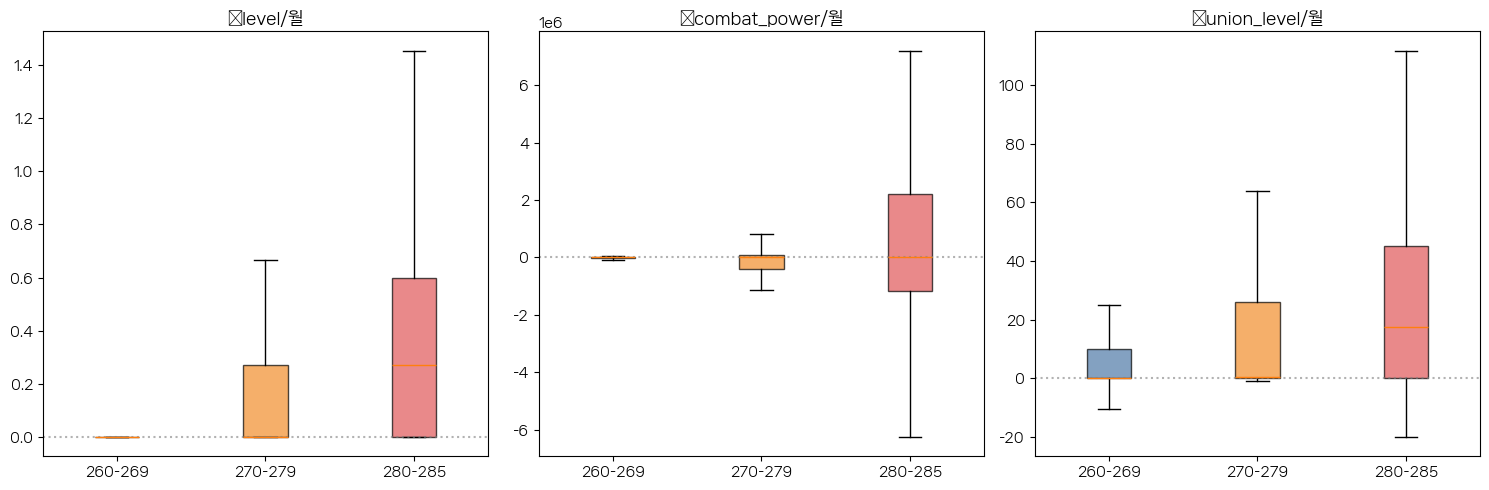

In [18]:
# 레벨 구간별 delta 분포 박스플롯 — 어디서 정체 신호가 강한가?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
targets = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power', 'avg_monthly_delta_union_level']
short = ['Δlevel/월', 'Δcombat_power/월', 'Δunion_level/월']
for ax, col, ti in zip(axes, targets, short):
    data = [df_clean[df_clean['level_bin'] == b][col].dropna() for b in LEVEL_BIN_ORDER]
    bp = ax.boxplot(data, labels=LEVEL_BIN_ORDER, patch_artist=True, showfliers=False)
    for patch, b in zip(bp['boxes'], LEVEL_BIN_ORDER):
        patch.set_facecolor(BIN_PALETTE[b])
        patch.set_alpha(0.7)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
    ax.set_title(ti)
plt.tight_layout()
plt.show()

## Sec 6. 경험치 신호 분석 (가설 외 탐색)

**가설**: 같은 레벨에서 경험치 백분위가 낮으면 해당 레벨에 오래 머문 유저(= 주차 후보).
H1 피처로 들어갈 수도 있지만 우선 탐색.


In [19]:
# 레벨 내 경험치 상대 위치 (백분위) — level==285는 만렙으로 exp=0 → 제외
df_exp = df_clean[df_clean['level'] < 285].copy()
df_exp['exp_rank_within_level'] = (df_exp.groupby('level')['exp']
                                   .rank(pct=True, method='average'))
print(f'경험치 분석 대상: {len(df_exp)}행 (level<285)')
print(df_exp['exp_rank_within_level'].describe().round(3).to_string())

경험치 분석 대상: 1628행 (level<285)
count    1628.000
mean        0.507
std         0.289
min         0.005
25%         0.257
50%         0.507
75%         0.758
max         1.000


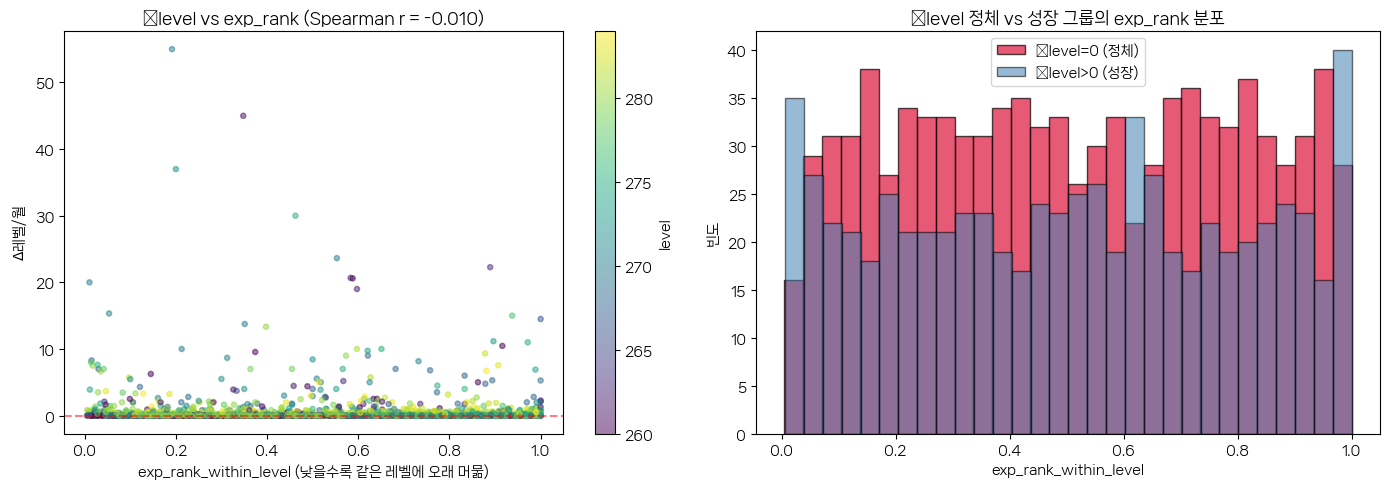

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Δlevel vs exp_rank (낮은 exp_rank + 0 Δlevel = 주차 강한 신호)
sc = axes[0].scatter(df_exp['exp_rank_within_level'], df_exp['avg_monthly_delta_level'],
                     c=df_exp['level'], cmap='viridis', alpha=0.5, s=14)
plt.colorbar(sc, ax=axes[0], label='level')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('exp_rank_within_level (낮을수록 같은 레벨에 오래 머묾)')
axes[0].set_ylabel(r'$\Delta$레벨/월')
axes[0].set_title(f'Δlevel vs exp_rank (Spearman r = {spearmanr(df_exp["exp_rank_within_level"], df_exp["avg_monthly_delta_level"], nan_policy="omit")[0]:.3f})')

# 오른쪽: Δlevel=0 그룹의 exp_rank 분포
axes[1].hist(df_exp.loc[df_exp['avg_monthly_delta_level'] == 0, 'exp_rank_within_level'],
             bins=30, alpha=0.7, label='Δlevel=0 (정체)', color='crimson', edgecolor='black')
axes[1].hist(df_exp.loc[df_exp['avg_monthly_delta_level'] > 0, 'exp_rank_within_level'],
             bins=30, alpha=0.55, label='Δlevel>0 (성장)', color='steelblue', edgecolor='black')
axes[1].set_xlabel('exp_rank_within_level')
axes[1].set_ylabel('빈도')
axes[1].set_title('Δlevel 정체 vs 성장 그룹의 exp_rank 분포')
axes[1].legend()
plt.tight_layout()
plt.show()

## Sec 7. 심볼 완성도 분석 (가설 외 탐색)

아케인심볼은 124~260레벨에서 의미가 있는 컨텐츠 — 260+ 캐릭터는 대부분 포화(120). 포화 후 Δarcane=0은 자연 발생 → **0/1 이진화 권장**.


In [21]:
# 심볼 파생 변수
df_clean['arcane_saturated'] = (df_clean['arcane_symbol_score'] == ARCANE_MAX)
df_clean['arcane_stagnant'] = ((df_clean['arcane_symbol_score'] < ARCANE_MAX) &
                                (df_clean['avg_monthly_delta_arcane_symbol'] == 0))
AUTHENTIC_MAX = max(int(df_clean['authentic_symbol_score'].max()), 1)
df_clean['authentic_completion'] = df_clean['authentic_symbol_score'] / AUTHENTIC_MAX

print('[심볼 파생 변수]')
print(f'  arcane_saturated:  {df_clean["arcane_saturated"].sum()}명 ({df_clean["arcane_saturated"].mean()*100:.1f}%)')
print(f'  arcane_stagnant:   {df_clean["arcane_stagnant"].sum()}명 ({df_clean["arcane_stagnant"].mean()*100:.1f}%)  ← H1 피처로 사용')
print(f'  authentic 관측 MAX: {AUTHENTIC_MAX} (이론 상한 88)')

[심볼 파생 변수]
  arcane_saturated:  839명 (49.7%)
  arcane_stagnant:   450명 (26.7%)  ← H1 피처로 사용
  authentic 관측 MAX: 55 (이론 상한 88)


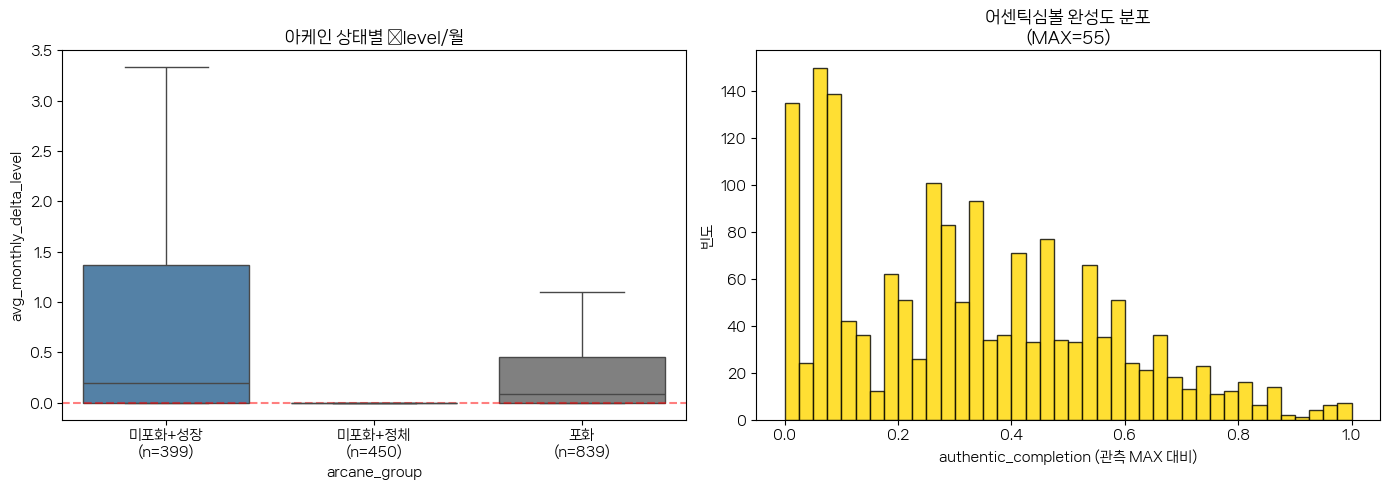

In [22]:
# 아케인 그룹별 Δlevel 비교
df_clean['arcane_group'] = '미포화+성장'
df_clean.loc[df_clean['arcane_stagnant'], 'arcane_group'] = '미포화+정체'
df_clean.loc[df_clean['arcane_saturated'], 'arcane_group'] = '포화'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 아케인 그룹 비교
order = ['미포화+성장', '미포화+정체', '포화']
sns.boxplot(data=df_clean, x='arcane_group', y='avg_monthly_delta_level',
            order=order, palette=['steelblue', 'crimson', 'gray'], ax=axes[0], showfliers=False)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('아케인 상태별 Δlevel/월')
counts = df_clean['arcane_group'].value_counts().reindex(order)
axes[0].set_xticklabels([f'{g}\n(n={counts[g]})' for g in order])

# 오른쪽: authentic_completion 분포
axes[1].hist(df_clean['authentic_completion'], bins=40, color='gold', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('authentic_completion (관측 MAX 대비)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'어센틱심볼 완성도 분포\n(MAX={AUTHENTIC_MAX})')
plt.tight_layout()
plt.show()

## Sec 8. 종합 성장 정체 지수 (stagnation_score)

5개 신호의 정체 정도를 0~5 점수로 합산해 주차 유저 규모를 사전 추정.
H1 라벨링 없이도 직관적인 후보군 파악 가능.


In [23]:
# 각 delta 피처가 하위 25%(P25) 이하이면 정체 신호 (1점)
delta_for_stag = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power',
                  'avg_monthly_delta_union_level', 'avg_monthly_delta_arcane_symbol',
                  'avg_monthly_delta_authentic_symbol']

df_clean['stagnation_score'] = 0
thresholds = {}
for col in delta_for_stag:
    q25 = df_clean[col].quantile(0.25)
    thresholds[col] = q25
    df_clean['stagnation_score'] += (df_clean[col] <= q25).astype(int)

print('[정체 임계치 (P25)]')
for c, v in thresholds.items():
    print(f'  {c}: {v:.3f}')

score_dist = df_clean['stagnation_score'].value_counts().sort_index()
print('\n[stagnation_score 분포]')
print(score_dist.to_string())
print(f'\nscore == 5 (모든 신호 정체): {(df_clean["stagnation_score"] == 5).sum()}명 '
      f'({(df_clean["stagnation_score"] == 5).mean()*100:.1f}%) ← 주차 강력 후보')

[정체 임계치 (P25)]
  avg_monthly_delta_level: 0.000
  avg_monthly_delta_combat_power: -305557.017
  avg_monthly_delta_union_level: 0.000
  avg_monthly_delta_arcane_symbol: 0.000
  avg_monthly_delta_authentic_symbol: 0.000

[stagnation_score 분포]
stagnation_score
0    264
1    359
2    351
3    172
4    487
5     55

score == 5 (모든 신호 정체): 55명 (3.3%) ← 주차 강력 후보


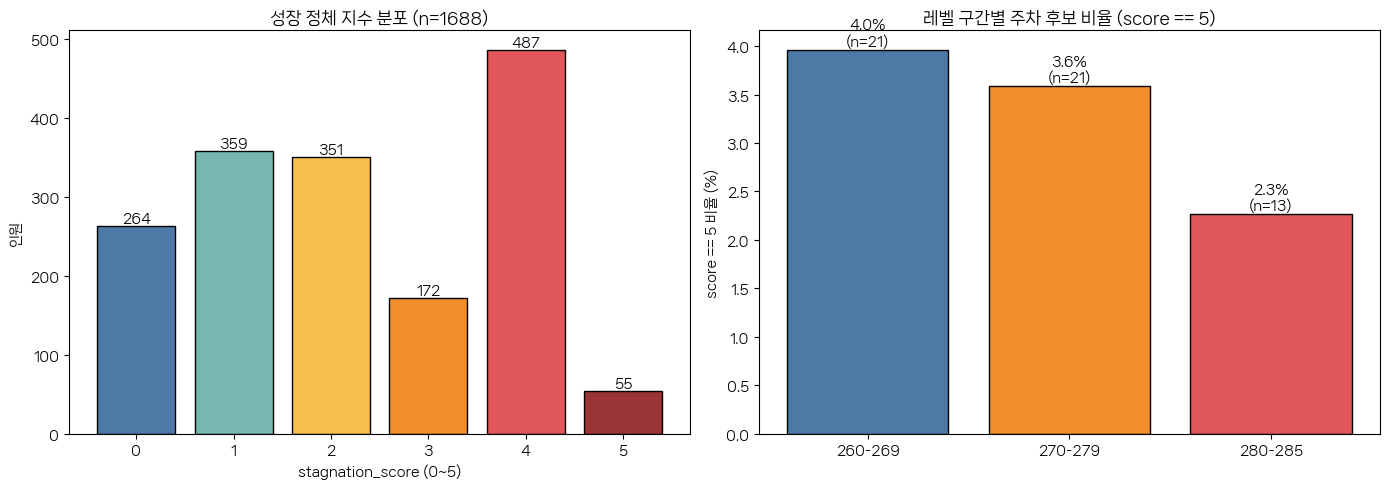

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 전체 분포
bars = axes[0].bar(score_dist.index.astype(str), score_dist.values,
                    color=['#4e79a7','#76b7b2','#f6c04f','#f28e2b','#e15759','#9b3434'],
                    edgecolor='black')
for b, v in zip(bars, score_dist.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, str(v), ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('stagnation_score (0~5)')
axes[0].set_ylabel('인원')
axes[0].set_title(f'성장 정체 지수 분포 (n={len(df_clean)})')

# 오른쪽: 레벨 구간 × score 5 비율
score5_by_bin = (df_clean.assign(s5=(df_clean['stagnation_score'] == 5).astype(int))
                 .groupby('level_bin')['s5'].mean() * 100)
score5_n = (df_clean[df_clean['stagnation_score'] == 5]
            .groupby('level_bin').size().reindex(LEVEL_BIN_ORDER, fill_value=0))
bars2 = axes[1].bar(LEVEL_BIN_ORDER, score5_by_bin.reindex(LEVEL_BIN_ORDER),
                    color=[BIN_PALETTE[b] for b in LEVEL_BIN_ORDER], edgecolor='black')
for b, pct, n in zip(bars2, score5_by_bin.reindex(LEVEL_BIN_ORDER), score5_n):
    axes[1].text(b.get_x() + b.get_width()/2, pct, f'{pct:.1f}%\n(n={n})',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('score == 5 비율 (%)')
axes[1].set_title('레벨 구간별 주차 후보 비율 (score == 5)')
plt.tight_layout()
plt.show()

### 파킹 사전 프록시(pre-label)에 대한 주의

EDA의 "주차 후보" 추정은 모두 **느슨한 사전 라벨**이며, 최종 라벨은 H1 군집 결과(`cluster_labels.csv`)다.
정의에 따라 비율이 크게 달라지므로 단일 수치로 해석하지 말 것:

| 프록시 | 정의 | 비율(df_clean, n=1,688) |
|---|---|---|
| Δlevel = 0 | 레벨만 정체 | 56.2% (너무 느슨 — 고렙 구간은 자연 성장도 느림) |
| **triple-zero** | Δlevel = Δcp = Δunion = 0 | **29.3% (주 사전 프록시)** |
| stagnation_score = 5 | 5개 신호 모두 P25 이하 | 3.3% (매우 보수적; Δcp의 P25는 큰 음수라 파킹과 약하게 역상관) |

→ 가장 방어 가능한 단일 사전 프록시는 **triple-zero ≈ 29%**. v1(3.8%) 대비 신호 비율이 크게 개선되어
H1 군집 분리·H3 소수 클래스 표본 확보에 충분하다. 실제 검정(H2)·rule 학습(H3)은 H1 군집 라벨을 입력으로 사용한다.

## Sec 9. 가설 검증 가능성 체크리스트

EDA 결과를 바탕으로 H1/H2/H3 실현 가능성을 정량 판단.


In [25]:
print('=' * 55)
print('H1 체크리스트: K-Means / DBSCAN 클러스터 분리 가능성')
print('=' * 55)
zero_pct = (df_clean['avg_monthly_delta_level'] == 0).mean() * 100
print(f'  ✓ 샘플 크기: {len(df_clean)}명 (충분: >1,000)')
print(f'  ✓ Δlevel=0 비율: {zero_pct:.1f}%  (주차 후보군 명확)')
print(f'  ✓ VIF 모두 < 5: 다중공선성 없음 (Sec 3)')
print(f'  ✓ stagnation_score=5: {(df_clean["stagnation_score"]==5).sum()}명 ({(df_clean["stagnation_score"]==5).mean()*100:.1f}%) — 의미있는 군집 형성 기대')
print('  → 피처 셋: [Δlevel, Δcp(winsorize), Δunion, Δauthentic, arcane_stagnant] (Sec 10)')

H1 체크리스트: K-Means / DBSCAN 클러스터 분리 가능성
  ✓ 샘플 크기: 1688명 (충분: >1,000)
  ✓ Δlevel=0 비율: 56.2%  (주차 후보군 명확)
  ✓ VIF 모두 < 5: 다중공선성 없음 (Sec 3)
  ✓ stagnation_score=5: 55명 (3.3%) — 의미있는 군집 형성 기대
  → 피처 셋: [Δlevel, Δcp(winsorize), Δunion, Δauthentic, arcane_stagnant] (Sec 10)


In [26]:
print('=' * 55)
print('H2 체크리스트: Chi-Square 검증 가능성')
print('=' * 55)
# 레벨 구간
ct_lv = pd.crosstab(df_clean['level_bin'], parked_proxy.map({True: '주차후보', False: '정상'}))
chi2, p, dof, expected = chi2_contingency(ct_lv)
ok_lv = expected.min() >= 5
print(f'  레벨 구간 (3 bins × 2): 기대빈도 min={expected.min():.1f}  → {"OK" if ok_lv else "부족"}')
print(f'    χ²={chi2:.1f}, p={p:.2e}')

# 직업 계열 (5계열만)
ct_cls = pd.crosstab(df_clean.loc[mask_5, 'class_group'],
                     parked_proxy[mask_5].map({True: '주차후보', False: '정상'}))
chi2, p, dof, expected = chi2_contingency(ct_cls)
ok_cls = expected.min() >= 5
print(f'  직업 계열 (5 × 2): 기대빈도 min={expected.min():.1f}  → {"OK" if ok_cls else "Fisher exact 권장"}')
print(f'    χ²={chi2:.1f}, p={p:.2e}')

print('  → H1 cluster_labels.csv 생성 후 본 검정 진행. EDA 사전 결과 양호.')

H2 체크리스트: Chi-Square 검증 가능성
  레벨 구간 (3 bins × 2): 기대빈도 min=155.4  → OK
    χ²=123.1, p=1.83e-27
  직업 계열 (5 × 2): 기대빈도 min=87.1  → OK
    χ²=15.0, p=4.75e-03
  → H1 cluster_labels.csv 생성 후 본 검정 진행. EDA 사전 결과 양호.


In [27]:
print('=' * 55)
print('H3 체크리스트: Feature Importance + Rule 식별 가능성')
print('=' * 55)
parked_rate = parked_proxy.mean()
n_parked = parked_proxy.sum()
n_total = len(df_clean)
print(f'  소수 클래스 비율: {parked_rate*100:.1f}%  ({n_parked}/{n_total}명)')
print(f'  5-fold CV per-fold 소수 클래스 평균: ~{n_parked/5:.0f}명  (충분: ≥30)')
print(f'  → class_weight="balanced" 또는 scale_pos_weight={(n_total-n_parked)/n_parked:.1f} 권장')
print(f'  → Precision 95% CI는 약 ±{1.96 * np.sqrt(0.95*0.05/(n_parked/5)) * 100:.1f}%p (5-fold 평균)')
print(f'  → 목표 Precision > 0.95 달성 시 통계적으로 유의한 마진 확보 가능')

H3 체크리스트: Feature Importance + Rule 식별 가능성
  소수 클래스 비율: 29.3%  (495/1688명)
  5-fold CV per-fold 소수 클래스 평균: ~99명  (충분: ≥30)
  → class_weight="balanced" 또는 scale_pos_weight=2.4 권장
  → Precision 95% CI는 약 ±4.3%p (5-fold 평균)
  → 목표 Precision > 0.95 달성 시 통계적으로 유의한 마진 확보 가능


## Sec 10. 최종 전처리 결정 및 클러스터링 피처셋 확정

H1/H2/H3 노트북이 각자 `features_monthly.csv`를 로드해 동일한 전처리를 재현할 수 있도록, **이 섹션에서 모든 결정을 코드로 명시한다**.


In [28]:
# ── 최종 전처리 함수 (H1/H2/H3 노트북에서 재사용) ─────────────────────────
def preprocess(features_path='../data/features_monthly.csv',
               main_path='../data/main_characters.csv'):
    """
    EDA에서 확정한 전처리 결정을 일괄 적용해 분석용 데이터프레임 반환.

    수행 내용:
      1) features_monthly.csv 로드 + main_characters.csv 의 class_group 병합
      2) 프로젝트 범위(260≤level≤285)로 필터 — 수집 의도 외 행 제거
      3) level_bin 생성 (260-269 / 270-279 / 280-285)
      4) 핵심 delta(level/cp/union) NaN 행 listwise 제거
      5) delta_arcane / delta_authentic 음수 → 0 클램프 (시스템상 불가)
      6) union_level NaN → 0 (유니온 미가입)
      7) delta_combat_power Winsorize [P5, P95]
      8) arcane_stagnant 이진 피처 생성 (포화 미달 + 변화 없음)
    """
    df = pd.read_csv(features_path, encoding='utf-8-sig')
    mc = pd.read_csv(main_path, encoding='utf-8-sig', usecols=['ocid', 'class_group'])
    df = df.merge(mc, on='ocid', how='left')

    # 프로젝트 분석 범위
    df = df[df['level'].between(260, 285)].copy()

    df['level_bin'] = pd.cut(df['level'], bins=[259, 269, 279, 285],
                              labels=['260-269', '270-279', '280-285'])

    core = ['avg_monthly_delta_level',
            'avg_monthly_delta_combat_power',
            'avg_monthly_delta_union_level']
    df = df.dropna(subset=core).copy()

    for c in ['avg_monthly_delta_arcane_symbol', 'avg_monthly_delta_authentic_symbol']:
        df.loc[df[c] < 0, c] = 0

    df['union_level'] = df['union_level'].fillna(0)

    df['delta_cp_winsor'] = winsorize(df['avg_monthly_delta_combat_power'].values,
                                       limits=[0.05, 0.05])

    df['arcane_stagnant'] = ((df['arcane_symbol_score'] < 120) &
                              (df['avg_monthly_delta_arcane_symbol'] == 0)).astype(int)
    return df


# 확정 — 이 df_final 이 H1/H2/H3 의 출발점이다.
df_final = preprocess()
print(f'df_final: {df_final.shape}')

df_final: (1688, 22)


In [29]:
# ── 클러스터링 피처 셋 (H1) ────────────────────────────────────────────────
CLUSTER_FEATURES = [
    'avg_monthly_delta_level',          # 핵심 정체 신호
    'delta_cp_winsor',                  # P5-P95 winsorize 적용
    'avg_monthly_delta_union_level',    # 핵심 정체 신호
    'avg_monthly_delta_authentic_symbol',  # 280+ 성장 신호
    'arcane_stagnant',                  # 이진 피처
]
print('[H1 클러스터링 피처]')
for f in CLUSTER_FEATURES:
    print(f'  - {f}')
print(f'\n총 {len(CLUSTER_FEATURES)}개. StandardScaler 적용 후 K-Means/DBSCAN.')

# 결측 재확인
print('\n[결측 점검]')
print(df_final[CLUSTER_FEATURES].isnull().sum().to_string())

[H1 클러스터링 피처]
  - avg_monthly_delta_level
  - delta_cp_winsor
  - avg_monthly_delta_union_level
  - avg_monthly_delta_authentic_symbol
  - arcane_stagnant

총 5개. StandardScaler 적용 후 K-Means/DBSCAN.

[결측 점검]
avg_monthly_delta_level               0
delta_cp_winsor                       0
avg_monthly_delta_union_level         0
avg_monthly_delta_authentic_symbol    0
arcane_stagnant                       0


In [30]:
# ── H2/H3 사용 데이터프레임 정리 ───────────────────────────────────────────
# class_group 은 수집 단계에서 5계열로 층화 완료(기타/결측 없음) → 방어적 필터만 적용
df_h2_class = df_final[df_final['class_group'].isin(GROUP_ORDER)].copy()
print(f'H2 (직업×cluster 검정) 대상: {len(df_h2_class)}행 (5계열 전체)')
print(f'H2 (레벨구간×cluster 검정) 대상: {len(df_final)}행 (전체)')

# H3: 모든 행 사용 (직업명은 피처가 아니라 군집/rule만 평가)
print(f'H3 (rule 평가) 대상: {len(df_final)}행 (전체)')

H2 (직업×cluster 검정) 대상: 1688행 (5계열 전체)
H2 (레벨구간×cluster 검정) 대상: 1688행 (전체)
H3 (rule 평가) 대상: 1688행 (전체)


In [31]:
# ── EDA 종합 요약 ──────────────────────────────────────────────────────────
print('=' * 60)
print('EDA 종합 요약 — v2 데이터')
print('=' * 60)
print(f'\n[데이터]')
print(f'  원본 features_monthly.csv: {len(df_raw)}행')
print(f'  분석 가능 (df_final): {len(df_final)}행 ({len(df_final)/len(df_raw)*100:.1f}%)')
print(f'  레벨 분포: {df_final["level"].min():.0f} ~ {df_final["level"].max():.0f} | class_group: 5계열 균형')

_proxy_final = ((df_final['avg_monthly_delta_level'] == 0) &
                (df_final['avg_monthly_delta_combat_power'] == 0) &
                (df_final['avg_monthly_delta_union_level'] == 0))
_rate = _proxy_final.mean() * 100

print(f'\n[가설 검증 가능성]')
print(f'  H1: 피처 5개 / VIF 통과 / Δlevel=0 비율 {(df_final["avg_monthly_delta_level"]==0).mean()*100:.0f}%  → 진행 가능')
print(f'  H2: 레벨구간 3 × 5계열 / 기대빈도 ≥5  → 진행 가능 (5계열 전체)')
print(f'  H3: parked_proxy(triple-zero) {_rate:.1f}% — 주 EDA 사전 프록시(느슨, H1 라벨로 대체) → fold당 충분, 진행 가능')

print(f'\n[다음 단계]')
print(f'  1) h1_clustering/h1_clustering.ipynb: preprocess() + CLUSTER_FEATURES → K-Means/DBSCAN')
print(f'     출력: data/cluster_labels.csv')
print(f'  2) h2_distribution/h2_distribution.ipynb: cluster_labels × {{level_bin, class_group}} 카이제곱')
print(f'  3) h3_rule/h3_rule.ipynb: cluster_labels pseudo-label → RF/XGB → Rule + threshold sweep')

EDA 종합 요약 — v2 데이터

[데이터]
  원본 features_monthly.csv: 2000행
  분석 가능 (df_final): 1688행 (84.4%)
  레벨 분포: 260 ~ 285 | class_group: 5계열 균형

[가설 검증 가능성]
  H1: 피처 5개 / VIF 통과 / Δlevel=0 비율 56%  → 진행 가능
  H2: 레벨구간 3 × 5계열 / 기대빈도 ≥5  → 진행 가능 (5계열 전체)
  H3: parked_proxy(triple-zero) 29.3% — 주 EDA 사전 프록시(느슨, H1 라벨로 대체) → fold당 충분, 진행 가능

[다음 단계]
  1) h1_clustering/h1_clustering.ipynb: preprocess() + CLUSTER_FEATURES → K-Means/DBSCAN
     출력: data/cluster_labels.csv
  2) h2_distribution/h2_distribution.ipynb: cluster_labels × {level_bin, class_group} 카이제곱
  3) h3_rule/h3_rule.ipynb: cluster_labels pseudo-label → RF/XGB → Rule + threshold sweep


# 종합 인사이트 — 가설별 정리

위 EDA 실행 결과(v2)를 가설별로 정리한다. 모든 수치는 분석 본판 `df_clean`/`df_final`(n=**1,688**, 원본 2,000명의 84.4%) 기준이며, 파킹 라벨은 EDA 사전 프록시(**triple-zero**: Δlevel=Δcp=Δunion=0, 29.3%)다 — 최종 라벨은 H1 군집이 산출한다.

## 공통 데이터 기반

- **샘플**: 2,000 → 1,688명. 제거 312명은 핵심 delta NaN(311) + 범위 외 레벨. `class_group`은 수집 단계에서 **5계열 × 400명 완전 균형**(전사/마법사/궁수/도적/해적, 기타·결측 0)으로 확보됨.
- **결측은 MCAR에 가깝다**: 핵심 delta 결측 행 레벨 평균 272.0 vs 정상 행 273.0 → listwise deletion 무편향. `num_valid_months`는 전 행 12지만 이는 `character/basic` 응답 횟수일 뿐, 필드 단위 결측(Δlevel NaN 250, Δunion NaN 311)은 별도로 존재.

## H1 (비지도 — 군집 분리 가능성) ✅ 진행 가능

**근거**
- **이중 구조 확인** (Sec 2, [히스토그램](README_files/README_11_0.png)): Δlevel 0값 56.2%, Δunion 0값 41.4%, Δcp 0값 30.8% — 0 부근 좁은 봉우리(=정체/파킹 후보)와 분산된 꼬리(=정상 성장)로 갈린다. 군집이 형성될 시각적 토대.
- **다중공선성 없음** (Sec 3, VIF): 5개 delta 피처 VIF 전부 < 5 (최대 3.36, arcane↔authentic). 차원 축소 불필요, 피처 5개 모두 유지.
- **심볼 포화 보정**: arcane 포화(=120) 49.7% → 포화 후 Δarcane=0은 자연 발생. 이를 분리한 `arcane_stagnant`(미포화+무변화) 이진 피처가 26.7%로 유효 신호.
- **스케일 처리 필수**: Δcp는 ±수천만 분산(std 4.28M)·35.5% 음수 → `winsorize(P5–P95)` 후 `StandardScaler` 적용해 K-Means 거리 왜곡 방지.

**확정 피처셋 (Feature Set A)**: `[Δlevel, delta_cp_winsor, Δunion, Δauthentic, arcane_stagnant]`
**판정**: 사전 프록시 29.3%가 하나의 군집과 정렬될 것으로 기대 → Acceptance(Silhouette ≥ 0.4 AND K-Means/DBSCAN ARI ≥ 0.7) 검증 준비 완료.

## H2 (통계 — 레벨·직업 분포 불균형) ✅ 두 교차표 모두 H0 기각

**근거 (사전 프록시 기준; 본검정은 H1 라벨로 재실행)**
- **레벨 구간 × 파킹** (Sec 5): χ² = 123.1, **p = 1.8e-27**, 최소 기대빈도 155.4. 파킹 비율이 **260-269 43.8% → 270-279 31.6% → 280-285 13.6%** 로 단조 감소 → 낮은 레벨대에 파킹 집중. "특정 레벨에서 성장을 멈추고 보스 파밍" 가설과 정확히 부합.
- **직업 계열 × 파킹** (Sec 4): χ² = 15.0, **p = 4.8e-3**, 최소 기대빈도 87.1. **해적 35.2%·도적 33.4%** (과대표집) vs **궁수 25.4%·전사 25.7%·마법사 25.9%** (과소). 보스 솔격·파밍 효율이 높은 직업군에 파킹이 쏠리는 경향.
- 모든 셀 기대빈도 ≥ 5 → χ² 가정 충족, Fisher exact 불필요.

**판정**: H2 "적어도 하나의 교차표가 H0 기각" 조건 충족(둘 다 기각). 본검정에서 **표준화 잔차**로 over-represented 셀(260-269 구간, 해적·도적)을 정량 지목 예정.

## H3 (지도 — Feature Importance 기반 Rule) ✅ 진행 가능

**근거**
- **소수 클래스 표본 충분**: 파킹 pseudo-label 29.3%(495명) → 5-fold CV per-fold ~99명. `scale_pos_weight ≈ 2.4`(또는 `class_weight="balanced"`) 권장. Precision 95% CI ≈ ±4.3%p → 목표 **Precision > 0.95** 유의 마진 확보 가능.
- **Rule 핵심 신호 (EDA 시사)**: triple-zero(Δlevel·Δunion·Δcp ≈ 0)가 1차 판별축. 보조로 `arcane_stagnant`, 그리고 **280+ 구간은 Δauthentic이 강한 판별자** — 어센틱 성장 median이 260-269 0 → 280-285 **1.727** 로, 고레벨에서 active(성장)와 parked(정체)를 가른다.

**판정**: RF/XGBoost Feature Importance → SHAP → threshold sweep으로 **Precision > 0.95 & FPR < 5%** Rule 도출 준비 완료.

## 탐색 결과 (가설 외) — 피처 채택/제외 근거

- **❌ `exp_rank_within_level`은 파킹 신호가 아니다** (Sec 6): 같은 레벨 내 경험치 백분위와 Δlevel의 Spearman **r = −0.010 (p = 0.69, 무상관)**. 직관과 달리 "같은 레벨에 오래 머묾 = 낮은 exp 백분위"가 성립하지 않음 → 피처에서 **제외**(정당한 근거 확보).
- **Δauthentic의 레벨 의존성** (Sec 4/7): 어센틱 성장은 고레벨 전용 신호(median 260-269 0 → 280-285 1.727). 280+ 파킹 탐지의 핵심 보조 피처.
- **`stagnation_score=5`(P25 기반)는 보수적 지표** (Sec 8): 3.3%(55명)에 불과. Δcp의 P25가 큰 음수라 파킹(Δcp≈0)과 역상관하기 때문 → 파킹 규모 추정에는 부적합. 주 사전 프록시로 **triple-zero**(29.3%)를 사용.
